## Landcover data


In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
landcover = gpd.read_file("/fs9/eliviau/hex2vec_project/land_use_framework/data/lc_250_tags") #specify which tags to use


In [2]:
landcover.head(30)

,feature_id,land_cover,geometry
0,0,Bare,"POLYGON ((148.75208 45.55833, 148.75417 45.558..."
1,1,Bare,"POLYGON ((148.78333 45.55625, 148.7875 45.5562..."
2,2,Bare,"POLYGON ((148.78958 45.55625, 148.79167 45.556..."
3,3,Bare,"POLYGON ((148.76042 45.55417, 148.7625 45.5541..."
4,4,Grassland,"POLYGON ((148.7625 45.55417, 148.76667 45.5541..."
5,5,Bare,"POLYGON ((148.76875 45.55417, 148.77083 45.554..."
6,6,Bare,"POLYGON ((148.78125 45.55417, 148.78333 45.554..."
7,7,Grassland,"POLYGON ((148.78333 45.55417, 148.78542 45.554..."
8,8,Grassland,"POLYGON ((148.7875 45.55417, 148.78958 45.5541..."
9,9,Grassland,"POLYGON ((148.79167 45.55417, 148.79583 45.554..."


In [3]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [5]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Hokkaido
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ea8b8effffff,"POLYGON ((144.13318 44.27438, 144.12933 44.286..."
872ef0d06ffffff,"POLYGON ((141.25121 44.57662, 141.24692 44.588..."
872ef2b85ffffff,"POLYGON ((140.79938 45.41073, 140.79497 45.422..."
872ef5a35ffffff,"POLYGON ((139.99553 43.26175, 139.99115 43.273..."
872ef6a10ffffff,"POLYGON ((141.65479 44.71187, 141.65055 44.724..."


In [6]:
regions.shape

(28902, 1)

step 3 : join 

In [7]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
landcover = landcover.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, landcover)

# Preview the result
joined.head()


Empty DataFrame
Columns: []
Index: [(872e8db63ffffff, 125), (872e8db63ffffff, 166), (872e8db60ffffff, 167), (872e8db63ffffff, 167), (872e8db63ffffff, 169)]

In [8]:
joined.shape

(460367, 0)

In [9]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    landcover[["feature_id", "land_cover"]],
    on="feature_id",
    how="left"
)

In [10]:
joined_with_tags.head()

,region_id,feature_id,land_cover
0,872e8db63ffffff,125,Bare
1,872e8db63ffffff,166,Bare
2,872e8db60ffffff,167,Bare
3,872e8db63ffffff,167,Bare
4,872e8db63ffffff,169,Wetland


In [11]:
ahp_landcover_scores = {
    "Cropland": 6,  # tbc with experts - political compromise
    "Grassland": 10,
    "Bare":10,
    "DBF": 3,
    "DNF": 3,
    "EBF": 3,
    "ENF": 3,
    "Wetland": 6,  #
    "Water": 4, #SEE SOLAR PP on waterlands - but not river
    "Built-up": 7, #tricky variable --> rooftops vs prximity to villages...
    "Solar Panel": None,
    "Paddy Field": 0,
    "Greenhouse": 0,
    "Bamboo Forest": 1,
    "NULL": None
}


In [12]:
joined_with_tags["landcover_score"] = joined_with_tags["land_cover"].map(ahp_landcover_scores)


In [13]:
hex_scores = joined_with_tags.groupby("region_id")["landcover_score"].mean().reset_index()
hex_scores.columns = ["region_id", "landcover_score"]


In [14]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [15]:
regions_scored.head(30)

,region_id,geometry,landcover_score
0,872ea8b8effffff,"POLYGON ((144.13318 44.27438, 144.12933 44.286...",4.000000
1,872ef0d06ffffff,"POLYGON ((141.25121 44.57662, 141.24692 44.588...",4.000000
2,872ef2b85ffffff,"POLYGON ((140.79938 45.41073, 140.79497 45.422...",4.000000
3,872ef5a35ffffff,"POLYGON ((139.99553 43.26175, 139.99115 43.273...",NaN
4,872ef6a10ffffff,"POLYGON ((141.65479 44.71187, 141.65055 44.724...",4.000000
5,872ea9718ffffff,"POLYGON ((142.78946 44.57751, 142.78539 44.589...",4.533333
6,872e1b774ffffff,"POLYGON ((141.00152 43.09473, 140.99729 43.106...",7.100000
7,872eac693ffffff,"POLYGON ((145.15534 44.38345, 145.15163 44.395...",4.000000
8,872ee4675ffffff,"POLYGON ((139.21804 41.81752, 139.21366 41.829...",4.000000
9,872ef2918ffffff,"POLYGON ((141.25561 45.32509, 141.25127 45.337...",4.000000


In [17]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_landcoverreso7fortechFINAL.geojson", driver="GeoJSON")

In [16]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "landcover_score", colormap="YlGnBu", opacity=0.6)
m.save("landcover_hokkaido_map.html")


KeyboardInterrupt: 

/tmp/ipykernel_134824/502409780.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


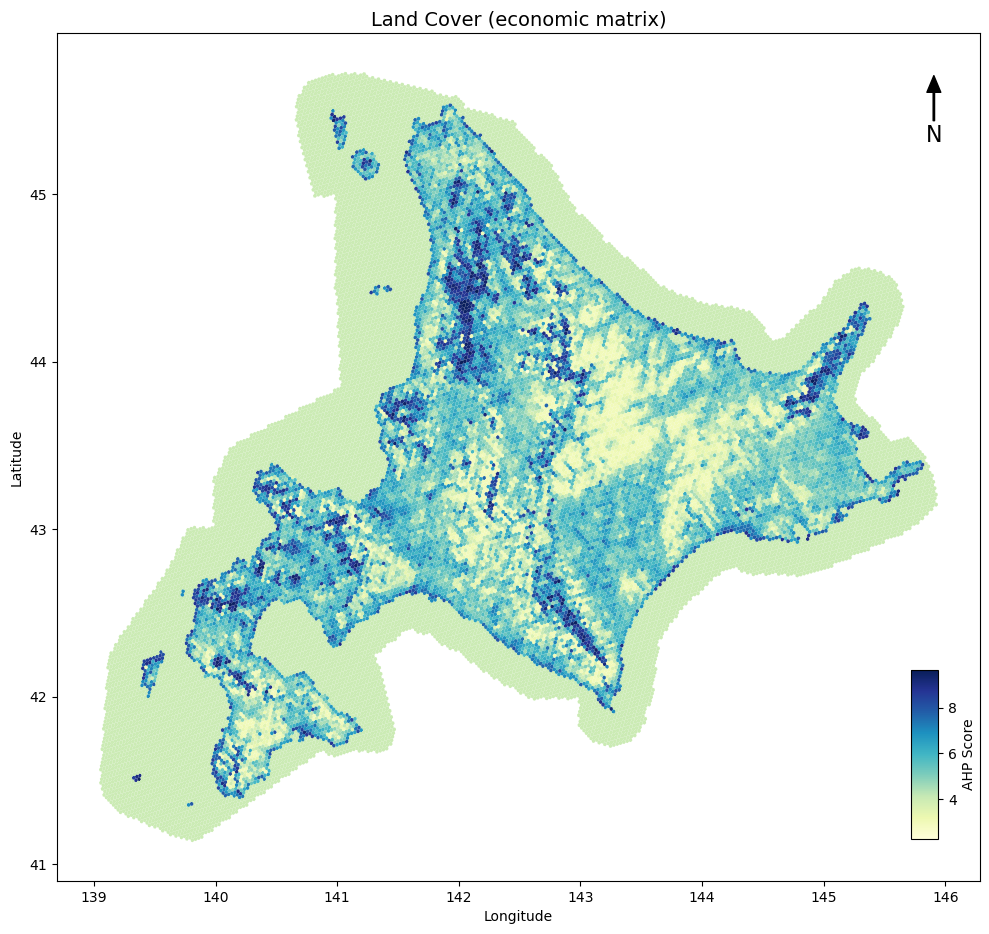

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='landcover_score',
    cmap='YlGnBu',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=regions_scored['landcover_score'].min(), vmax=regions_scored['landcover_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Land Cover (economic matrix)", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


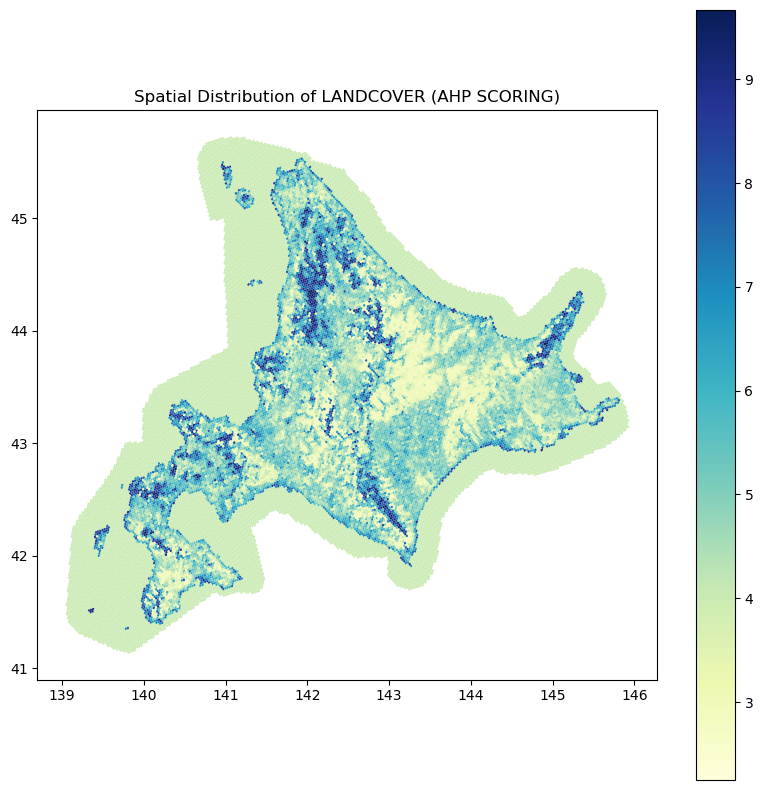

In [17]:
#other map 

#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='landcover_score',
    cmap='YlGnBu',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of LANDCOVER (AHP SCORING)")
plt.show()
